<a href="https://colab.research.google.com/github/hikaaru13/PCVK-GANJIL-TUGAS/blob/main/TUGAS_Aplikasi_Pertemuan2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TUGAS PRAKTIKUM PENERAPAN

NOMOR 1

(np.float64(-0.5), np.float64(353.5), np.float64(471.5), np.float64(-0.5))

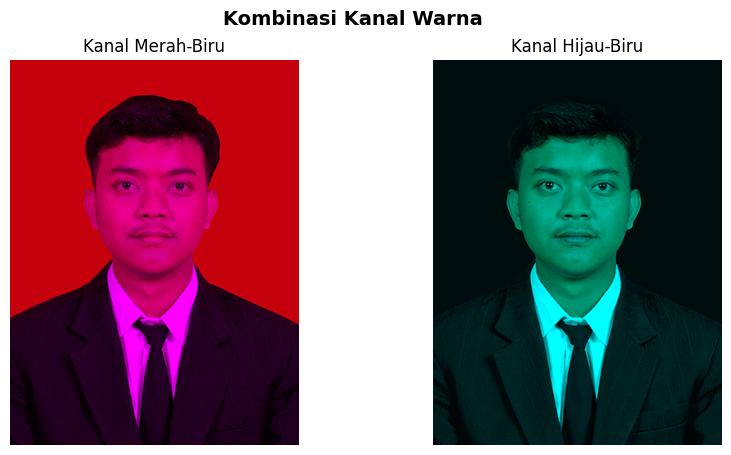

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Baca gambar dan konversi ke RGB
img = cv.imread('/content/drive/MyDrive/PCVK/2337300207-AHlOx.jpeg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Kanal Merah-Biru (Hijau dinolkan)
img_rb = img_rgb.copy()
img_rb[:, :, 1] = 0

# Kanal Hijau-Biru (Merah dinolkan)
img_gb = img_rgb.copy()
img_gb[:, :, 0] = 0

# Visualisasi dalam satu figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Kombinasi Kanal Warna', fontsize=14, fontweight='bold')

axes[0].imshow(img_rb)
axes[0].set_title('Kanal Merah-Biru')
axes[0].axis('off')

axes[1].imshow(img_gb)
axes[1].set_title('Kanal Hijau-Biru')
axes[1].axis('off')

NOMOR 2

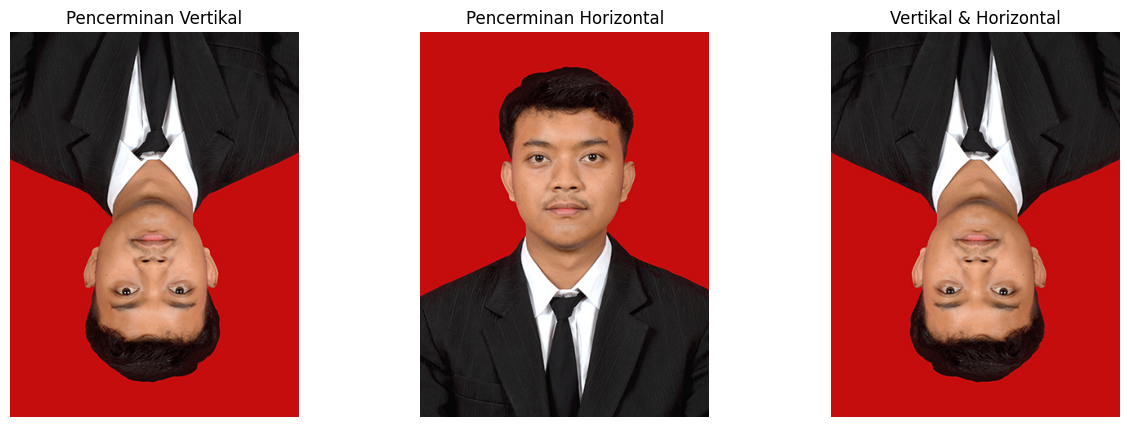

In [4]:
flip_v = cv.flip(img_rgb, 0)
flip_h = cv.flip(img_rgb, 1)
flip_both = cv.flip(img_rgb, -1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flip_v)
axes[0].set_title('Pencerminan Vertikal')
axes[0].axis('off')

axes[1].imshow(flip_h)
axes[1].set_title('Pencerminan Horizontal')
axes[1].axis('off')

axes[2].imshow(flip_both)
axes[2].set_title('Vertikal & Horizontal')
axes[2].axis('off')

plt.show()

NOMOR 3

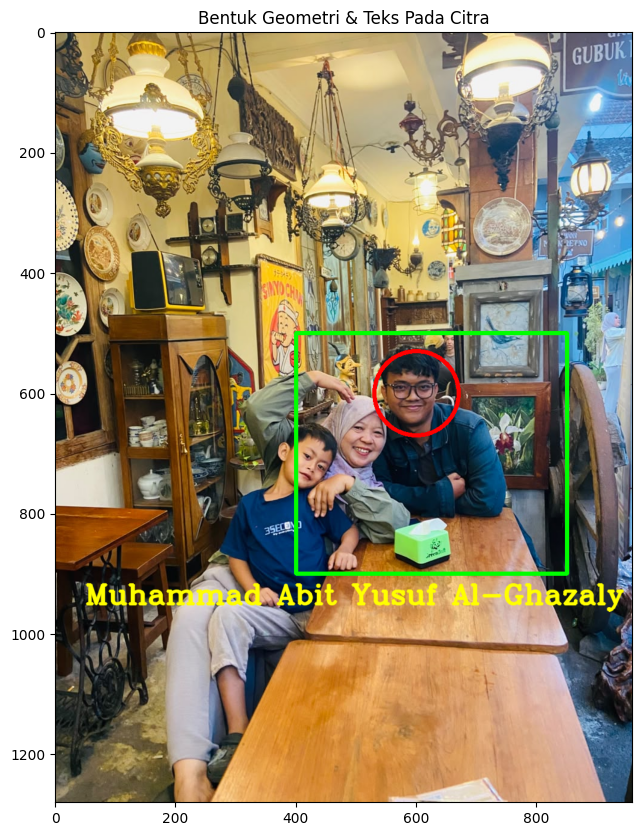

In [5]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Pastikan nama file sesuai
img_aktivitas = cv.imread('/content/drive/MyDrive/PCVK/FOTO_FORMAL.jpeg')
img_act_rgb = cv.cvtColor(img_aktivitas, cv.COLOR_BGR2RGB)

# Menggambar Rectangle (Kotak Hijau) di area badan
# Digeser ke kanan (sumbu x dari 550 sampai 850) dan ke bawah (sumbu y 600 ke 900)
cv.rectangle(img_act_rgb, pt1=(400, 500), pt2=(850, 900), color=(0, 255, 0), thickness=5)

# Menggambar Circle (Lingkaran Merah) di area wajah
# Digeser ke atas dan ke kanan (pusat x=670, y=630), radius diperkecil agar pas di wajah
cv.circle(img_act_rgb, center=(600, 600), radius=70, color=(255, 0, 0), thickness=5)

# Menambahkan Teks Nama (Kuning) di bagian bawah
# Titik awal (x) digeser ke 50 dan fontScale diturunkan menjadi 1.5 agar nama panjang tidak terpotong
font = cv.FONT_HERSHEY_COMPLEX
cv.putText(img_act_rgb, text='Muhammad Abit Yusuf Al-Ghazaly', org=(50, 950),
           fontFace=font, fontScale=1.5, color=(255, 255, 0), thickness=3, lineType=cv.LINE_AA)

# Visualisasi Hasil
plt.figure(figsize=(10, 10))
plt.imshow(img_act_rgb)
plt.title('Bentuk Geometri & Teks Pada Citra')
plt.show()

TUGAS PRAKTIKUM ANALISA

1. Pertanyaan Analisa"Apakah mengubah citra berwarna ke grayscale dengan metode average (rata-rata kanal) dan fungsi bawaan OpenCV (cv2.COLOR_BGR2GRAY) menghasilkan rata-rata intensitas piksel yang sama?"
2. Rancangan Program akan membaca satu citra berwarna, kemudian mengonversinya menjadi dua versi grayscale:Konversi manual menggunakan rumus rata-rata dari 3 kanal warna: $\frac{R + G + B}{3}$Konversi menggunakan fungsi OpenCV: cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)Setelah itu, program menghitung dan membandingkan nilai rata-rata intensitas piksel (np.mean()) dari kedua hasil konversi tersebut.

Rata-rata intensitas (Manual Average) : 119.57
Rata-rata intensitas (OpenCV GRAY)   : 124.96
Selisih nilai rata-rata               : 5.39


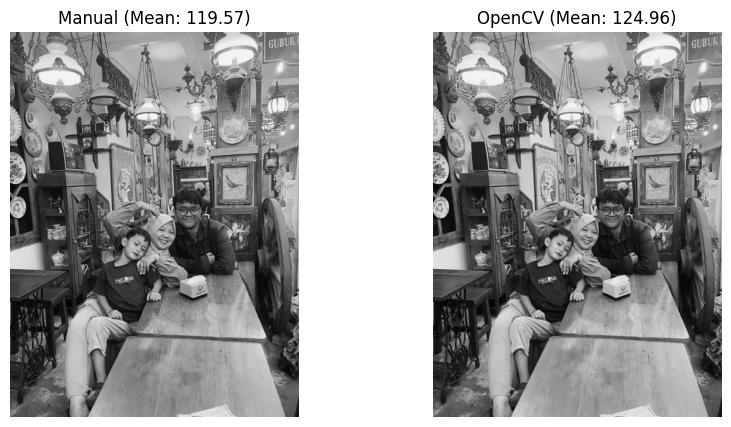

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca citra
img_bgr = cv2.imread('/content/drive/MyDrive/PCVK/FOTO_FORMAL.jpeg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# 2. Konversi Grayscale Manual (Rata-rata 3 Kanal)
# Mengubah ke float biar perhitungan tidak overflow
r, g, b = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
gray_manual = ((r.astype(np.float32) + g.astype(np.float32) + b.astype(np.float32)) / 3).astype(np.uint8)

# 3. Konversi Grayscale OpenCV (Luminance)
gray_opencv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# 4. Hitung Rata-rata Intensitas Piksel
mean_manual = np.mean(gray_manual)
mean_opencv = np.mean(gray_opencv)

# 5. Tampilkan Data Hasil
print(f"Rata-rata intensitas (Manual Average) : {mean_manual:.2f}")
print(f"Rata-rata intensitas (OpenCV GRAY)   : {mean_opencv:.2f}")
print(f"Selisih nilai rata-rata               : {abs(mean_manual - mean_opencv):.2f}")

# Plot Perbandingan Visual
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_manual, cmap='gray')
axes[0].set_title(f'Manual (Mean: {mean_manual:.2f})')
axes[0].axis('off')

axes[1].imshow(gray_opencv, cmap='gray')
axes[1].set_title(f'OpenCV (Mean: {mean_opencv:.2f})')
axes[1].axis('off')

plt.show()

TUGAS PRAKTIKUM APLIKASI

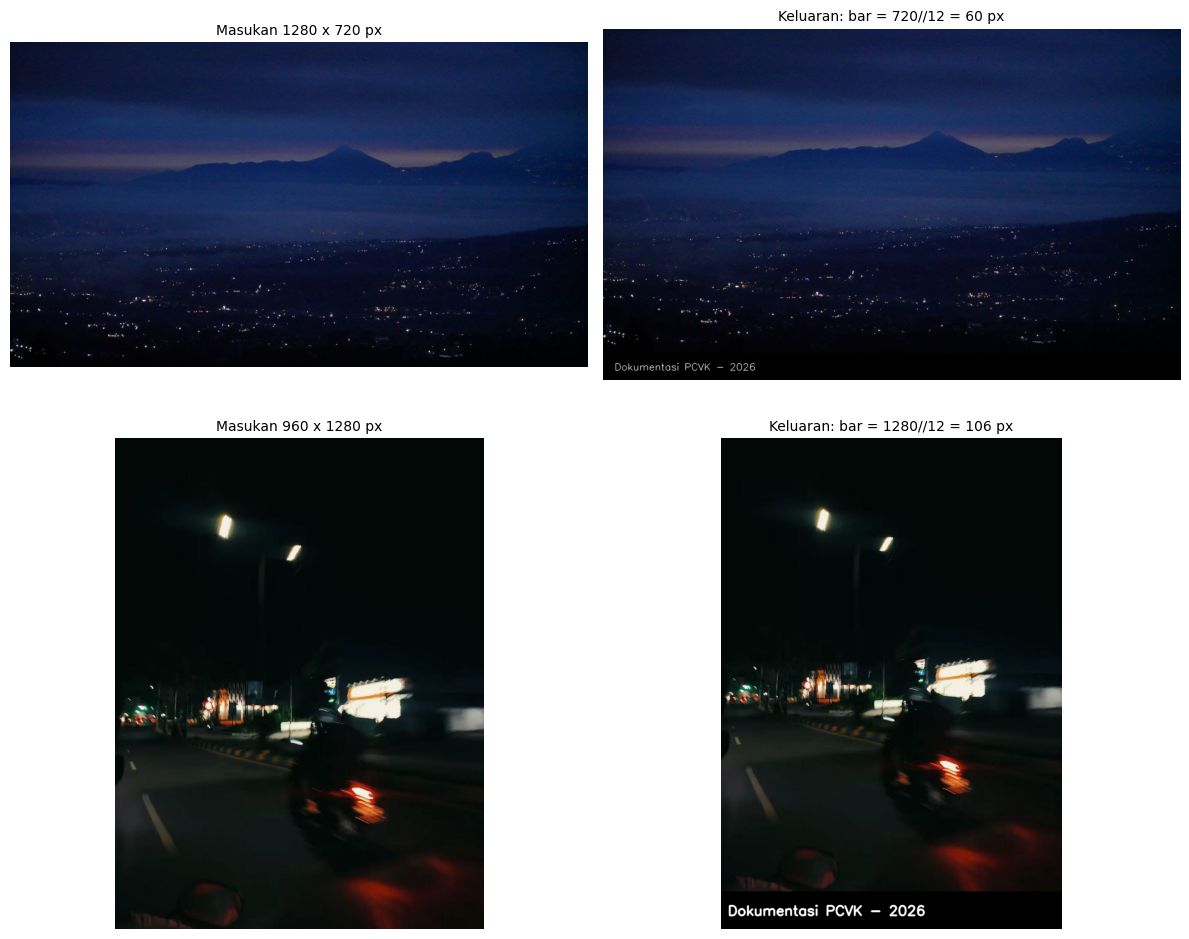

In [11]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def label_dokumentasi(image_path, teks):
    img = cv.imread(image_path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    bar_height = h // 12

    canvas = np.zeros((h + bar_height, w, 3), dtype=np.uint8)
    canvas[:h, :] = img_rgb

    font_scale = h / 1000
    thickness = max(1, int(h / 400))

    (text_w, text_h), _ = cv.getTextSize(teks, cv.FONT_HERSHEY_SIMPLEX, font_scale, thickness)
    text_x = int(w * 0.02)
    text_y = h + (bar_height + text_h) // 2

    cv.putText(canvas, teks, (text_x, text_y), cv.FONT_HERSHEY_SIMPLEX,
               font_scale, (255, 255, 255), thickness, cv.LINE_AA)

    return img_rgb, canvas, w, h, bar_height

img_ori_1, img_hasil_1, w1, h1, bar1 = label_dokumentasi('/content/drive/MyDrive/PCVK/LANSKAPE.jpeg', 'Dokumentasi PCVK - 2026')
img_ori_2, img_hasil_2, w2, h2, bar2 = label_dokumentasi('/content/drive/MyDrive/PCVK/POTRAIT.jpeg', 'Dokumentasi PCVK - 2026')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(img_ori_1)
axes[0, 0].set_title(f'Masukan {w1} x {h1} px', fontsize=10)
axes[0, 0].axis('off')

axes[0, 1].imshow(img_hasil_1)
axes[0, 1].set_title(f'Keluaran: bar = {h1}//12 = {bar1} px', fontsize=10)
axes[0, 1].axis('off')

axes[1, 0].imshow(img_ori_2)
axes[1, 0].set_title(f'Masukan {w2} x {h2} px', fontsize=10)
axes[1, 0].axis('off')

axes[1, 1].imshow(img_hasil_2)
axes[1, 1].set_title(f'Keluaran: bar = {h2}//12 = {bar2} px', fontsize=10)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

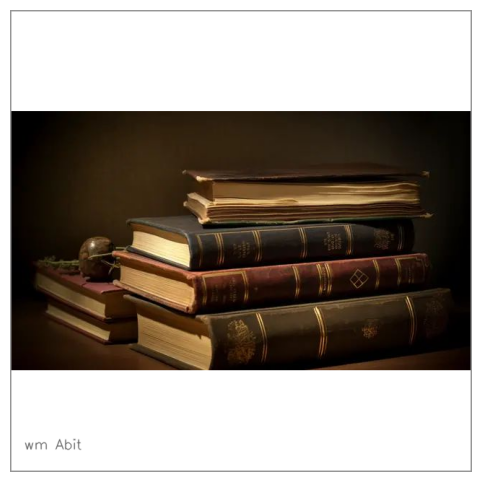

In [ ]:
def thumbnail_marketplace(image_path, nama_toko):
    img = cv.imread(image_path)
    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    sisi = max(h, w)

    canvas = np.full((sisi, sisi, 3), 255, dtype=np.uint8)

    y_offset = (sisi - h) // 2
    x_offset = (sisi - w) // 2
    canvas[y_offset:y_offset+h, x_offset:x_offset+w] = img_rgb

    cv.rectangle(canvas, (0, 0), (sisi-1, sisi-1), (150, 150, 150), 2)

    font_scale = sisi / 1000
    thickness = max(1, int(sisi / 400))
    cv.putText(canvas, nama_toko, (int(sisi * 0.03), int(sisi * 0.95)),
               cv.FONT_HERSHEY_SIMPLEX, font_scale, (100, 100, 100), thickness, cv.LINE_AA)

    return canvas

hasil_thumbnail = thumbnail_marketplace('/content/drive/MyDrive/PCVK/an antique stack of books has been placed in front of a dark background.jpg', 'wm Abit')

plt.figure(figsize=(6, 6))
plt.imshow(hasil_thumbnail)
plt.axis('off')
plt.show()